In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mlflow.set_tracking_uri("sqlite:///mlflow_tracking/mlflow.db")

In [2]:
experiment = mlflow.get_experiment_by_name("iris-hyperparameter-tuning")
print(f"Experiment ID: {experiment.experiment_id}")

runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
print(f"Total runs: {len(runs_df)}")

print("\n=== Experiment Summary ===")
print(runs_df[['run_id', 'params.model_type', 'metrics.test_accuracy', 'metrics.train_accuracy']].head(10))

2025/07/05 22:29:56 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/07/05 22:29:56 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


Experiment ID: 1
Total runs: 4

=== Experiment Summary ===
                             run_id    params.model_type  \
0  382e1f5b5f344e5cbee4870d68305c22                 None   
1  d475334dd70c46d987c34cf675081095                  svm   
2  361b98db7cf746c5af0a980e39d86c75        random_forest   
3  c318692872514318b3f68c5bd29e34c7  logistic_regression   

   metrics.test_accuracy  metrics.train_accuracy  
0                    NaN                     NaN  
1               1.000000                0.983333  
2               0.966667                0.966667  
3               0.966667                0.983333  


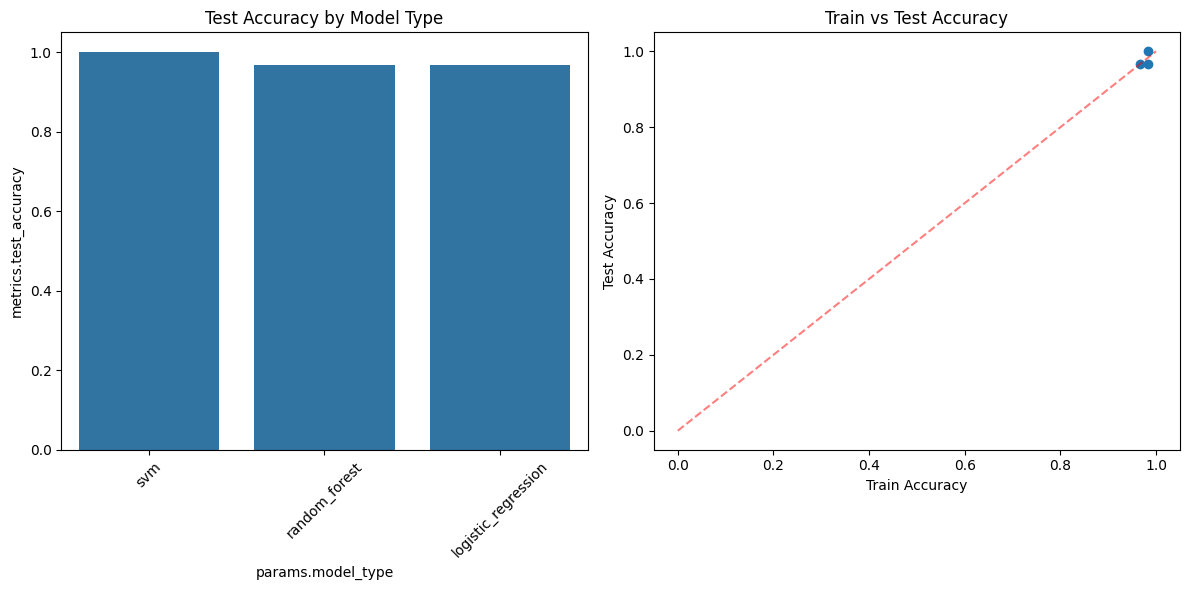


=== Best Model Details ===
Model Type: svm
Test Accuracy: 1.0000
Run ID: d475334dd70c46d987c34cf675081095


In [3]:
model_runs = runs_df[runs_df['tags.mlflow.runName'].str.contains('_best_model', na=False)]

if not model_runs.empty:
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    sns.barplot(data=model_runs, x='params.model_type', y='metrics.test_accuracy')
    plt.title('Test Accuracy by Model Type')
    plt.xticks(rotation=45)
    
    plt.subplot(1, 2, 2)
    plt.scatter(model_runs['metrics.train_accuracy'], model_runs['metrics.test_accuracy'])
    plt.xlabel('Train Accuracy')
    plt.ylabel('Test Accuracy')
    plt.title('Train vs Test Accuracy')
    
    plt.plot([0, 1], [0, 1], 'r--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

best_run = runs_df.loc[runs_df['metrics.test_accuracy'].idxmax()]
print(f"\n=== Best Model Details ===")
print(f"Model Type: {best_run['params.model_type']}")
print(f"Test Accuracy: {best_run['metrics.test_accuracy']:.4f}")
print(f"Run ID: {best_run['run_id']}")

In [8]:
import joblib
best_model_path = f"mlruns/{experiment.experiment_id}/{best_run['run_id']}/artifacts/model"

try:
    model = mlflow.sklearn.load_model(best_model_path)
    print("Model loaded successfully!")
    
    import joblib
    import numpy as np
    
    from iris_pipeline_mlflow import IrisMLflowPipeline
    pipeline = IrisMLflowPipeline()
    X_train, X_test, y_train, y_test, X, y = pipeline.load_data()
    
    predictions = model.predict(X_test)
    print(f"Sample predictions: {predictions[:5]}")
    print(f"Actual labels: {y_test.iloc[:5].values}")
    
except Exception as e:
    print(f"Could not load model from MLflow: {e}")
    print("Loading from local file instead...")
    model = joblib.load("model.pkl")
    print("Model loaded from local file successfully!")

Could not load model from MLflow: No such file or directory: 'mlruns/1/d475334dd70c46d987c34cf675081095/artifacts/model'
Loading from local file instead...
Model loaded from local file successfully!
